In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.optimize import minimize

# ── Plot style (consistent with Q1 Part 1) ────────────────────────────────
plt.rcParams.update({
    'font.family':       'serif',
    'font.size':         9,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linewidth':    0.5,
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
})

DARK  = '#1C1C1C'
RED   = '#C0392B'
BLUE  = '#2471A3'
GOLD  = '#B7950B'
GREEN = '#1E8449'

# Load portfolio returns (equal-weight: NVDA, AAPL, MSFT, IBM, GOOGL, AMZN)
ret_portfolio = pd.read_csv('portfolio_returns.csv', index_col=0, parse_dates=True).squeeze()
ret_portfolio.index = pd.DatetimeIndex(ret_portfolio.index)


# Q1 — Part 2: VaR and ES Estimation

**SMM272 Risk Analysis**

Covers:
1. Parameters and estimation setup  
2. Method 1 — Gaussian parametric  
3. Method 2 — Historical Simulation  
4. Method 3 — Student-t Method of Moments  
5. Method 4 — GARCH(1,1), rolling window  
6. Method 5 — GARCH(1,1), expanding window  
7. Figures  
8. VaR violations  
9. Backtesting

## 1 · Parameters

All methods share a common confidence level of 99% (tail probability 1%) and a rolling estimation window of 125 trading days, approximately six months. Estimation begins on 2 July 2014, the first date for which a full 125-day window of prior returns is available. The Gaussian quantile z_q = Φ⁻¹(0.01) = −2.326 and its density φ(z_q) are computed once and shared across all parametric methods.

In [7]:
# =============================================================================
# Parameters (shared across all loops)
# =============================================================================
ALPHA = 0.99
TAIL = 1 - ALPHA
START_DATE = pd.Timestamp('2014-07-02')

z_q   = stats.norm.ppf(TAIL)
phi_z = stats.norm.pdf(z_q)

estimation_dates = ret_portfolio.index[ret_portfolio.index.searchsorted(START_DATE):]

WINDOW_END_1 = ret_portfolio.index.searchsorted(START_DATE)  # first estimation index

## 2 · Method 1 — Gaussian Parametric

At each date t the rolling mean μ̂ and standard deviation σ̂ are estimated on the 125 observations ending at t−1. VaR and ES are then:

    VaRα = −(μ̂ + z_q · σ̂)
    ESα  = −(μ̂ − σ̂ · φ(z_q) / (1−α))

This is the simplest parametric approach and assumes returns within each window are i.i.d. normal. The stylised facts in Part 1, excess kurtosis of 6.34 and significant ARCH effects, suggest it will systematically understate tail risk.

In [8]:

# =============================================================================
# METHOD 1 — Gaussian
# =============================================================================
results_gaussian = pd.DataFrame(
    index   = estimation_dates,
    columns = ['VaR_Gaussian', 'ES_Gaussian'],
    dtype   = float
)

start, end = 0, WINDOW_END_1

for date in estimation_dates:
    window = ret_portfolio.iloc[start:end].values
    mu     = np.mean(window)
    sig    = np.sqrt(np.var(window, ddof=1))

    results_gaussian.loc[date, 'VaR_Gaussian'] = -(mu + z_q * sig)
    results_gaussian.loc[date, 'ES_Gaussian']  = -(mu - sig * phi_z / TAIL)

    start += 1; end += 1

print(f"Gaussian done — {len(results_gaussian)} estimates")

Gaussian done — 2873 estimates


## 3 · Method 2 — Historical Simulation

Historical Simulation (HS) makes no distributional assumption. VaR is the empirical 1st percentile of the sorted 125-day window, using linear interpolation between adjacent order statistics. ES is the probability-weighted average of all returns in the tail, with a fractional weight at the boundary observation to ensure the exact tail probability 1−α is covered.

With T = 125 and tail probability 0.01, the expected number of tail observations is m = 1.25, so k = 1 and q = 0.25. VaR is therefore interpolated between the worst and second-worst observation in the window, and ES averages just the single worst observation plus a fractional contribution from the boundary.

The main limitation of HS is the ghost effect: a large loss that enters the window causes an immediate jump in VaR, and its departure 125 days later causes an equally abrupt drop, regardless of current market conditions.

In [9]:

# =============================================================================
# METHOD 2 — Historical Simulation
# =============================================================================
results_hs = pd.DataFrame(
    index   = estimation_dates,
    columns = ['VaR_HS', 'ES_HS'],
    dtype   = float
)

start, end = 0, WINDOW_END_1

for date in estimation_dates:
    window   = ret_portfolio.iloc[start:end].values
    sorted_w = np.sort(window)          # ascending: sorted_w[0] = worst loss
    T_w      = len(window)
    m        = TAIL * T_w               # e.g. 0.01 * 125 = 1.25
    k        = int(np.floor(m))         # number of observations strictly below quantile
    q        = m - k                    # fractional weight on the (k+1)-th observation

    assert k >= 1, (
        f"Window too short for confidence level: T_w={T_w}, TAIL={TAIL}, m={m:.4f}, k={k}. "
        f"Need at least {int(1/TAIL) + 1} observations."
    )

    # VaR: interpolated quantile at level TAIL
    # if q == 0: m is integer, lands exactly on sorted_w[k-1]
    # if q > 0:  interpolate between sorted_w[k-1] and sorted_w[k]
    VaR_HS = -((1 - q) * sorted_w[k - 1] + q * sorted_w[k])

    # ES: equally weighted average of the k observations below the quantile
    # plus fractional weight q on the boundary observation sorted_w[k]
    ES_HS = -(1 / m) * (sorted_w[:k].sum() + q * sorted_w[k])

    results_hs.loc[date, 'VaR_HS'] = VaR_HS
    results_hs.loc[date, 'ES_HS']  = ES_HS

    start += 1; end += 1
print(f"Historical Simulation done — {len(results_hs)} estimates")

Historical Simulation done — 2873 estimates


## 4 · Method 3 — Student-t Method of Moments

The Student-t distribution accommodates fat tails through its degrees-of-freedom parameter ν. The Method of Moments estimator matches the theoretical excess kurtosis K(ν) = 6/(ν−4) to the sample excess kurtosis K̂ of the window, giving:

    ν̂ = 4 + 6/K̂

This requires K̂ > 0 and ν̂ > 4. When the rolling window exhibits non-positive excess kurtosis, which can occur during sustained directional moves that compress the distribution, the MoM estimator is undefined and the Gaussian formula is used as a fallback (the ν → ∞ limit of the Student-t).

### 4a · Diagnostic: rolling excess kurtosis

The diagnostic below plots rolling window excess kurtosis over the full estimation period and identifies the dates on which the Gaussian fallback applies.

── Rolling window excess kurtosis ──
count    2873.0000
mean        2.0547
std         2.4037
min        -0.6096
25%         0.6931
50%         1.3514
75%         2.4678
max        22.0255
Name: excess_kurt, dtype: float64

Days with excess_kurt <  0 : 235 (8.2%) — MoM undefined
Days with excess_kurt >= 0 : 2638 (91.8%) — MoM defined

── Implied nu on days where MoM is defined ──
count    2638.00
mean       15.21
std        89.00
min         4.27
25%         6.23
50%         8.01
75%        10.91
max      3740.65
Name: excess_kurt, dtype: float64

Days with nu > 30  (near-Gaussian) : 80
Days with nu > 100 (effectively Gaussian) : 30

── Excess kurtosis on negative days ──
count    235.0000
mean      -0.2717
std        0.1709
min       -0.6096
25%       -0.3836
50%       -0.2686
75%       -0.1461
max       -0.0018
Name: excess_kurt, dtype: float64

Conclusion: negative excess kurtosis is mild (min = -0.6096), Gaussian fallback (nu -> inf limit) is appropriate for all 235 days.


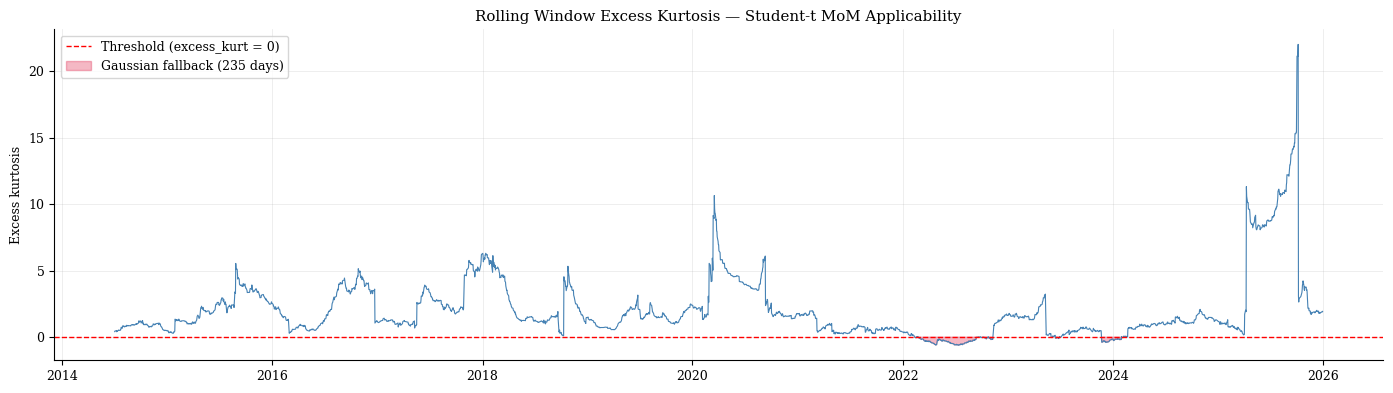

In [10]:
# =============================================================================
# METHOD 3 — Student-t Method of Moments: Pre-estimation diagnostics
# The Student-t(nu) distribution requires nu > 4 for finite kurtosis (MoM).
# The MoM estimator nu = 4 + 6/K is only defined when excess kurtosis K > 0.
# We first examine the rolling window excess kurtosis to understand how often
# and how severely this condition is violated before choosing the fallback rule.
# =============================================================================

# compute rolling excess kurtosis over all estimation windows
start, end = 0, WINDOW_END_1
ek_rows = []

for date in estimation_dates:
    window = ret_portfolio.iloc[start:end].values
    ek_rows.append({'date': date, 'excess_kurt': pd.Series(window).kurt()})
    start += 1; end += 1

ek_series = pd.DataFrame(ek_rows).set_index('date')['excess_kurt']

# implied nu for all positive excess kurtosis days
nu_implied = 4 + 6 / ek_series[ek_series > 0]

print("── Rolling window excess kurtosis ──")
print(ek_series.describe().round(4))
print(f"\nDays with excess_kurt <  0 : {(ek_series <  0).sum()} "
      f"({(ek_series < 0).mean():.1%}) — MoM undefined")
print(f"Days with excess_kurt >= 0 : {(ek_series >= 0).sum()} "
      f"({(ek_series >= 0).mean():.1%}) — MoM defined")

print("\n── Implied nu on days where MoM is defined ──")
print(nu_implied.describe().round(2))
print(f"\nDays with nu > 30  (near-Gaussian) : {(nu_implied > 30).sum()}")
print(f"Days with nu > 100 (effectively Gaussian) : {(nu_implied > 100).sum()}")

print("\n── Excess kurtosis on negative days ──")
print(ek_series[ek_series < 0].describe().round(4))
print(f"\nConclusion: negative excess kurtosis is mild (min = {ek_series.min():.4f}), "
      f"Gaussian fallback (nu -> inf limit) is appropriate for all {(ek_series < 0).sum()} days.")

# quick plot of rolling excess kurtosis
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(ek_series.index, ek_series.values, color='steelblue', linewidth=0.8)
ax.axhline(0, color='red',   linestyle='--', linewidth=1.0, label='Threshold (excess_kurt = 0)')
ax.fill_between(ek_series.index, ek_series.values, 0,
                where=(ek_series < 0), color='crimson', alpha=0.3,
                label=f'Gaussian fallback ({(ek_series < 0).sum()} days)')
ax.set_title('Rolling Window Excess Kurtosis — Student-t MoM Applicability')
ax.set_ylabel('Excess kurtosis')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig9_student_t_kurtosis_diagnostic.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

### 4b · Student-t estimation

On days where K̂ > 0, the scaled volatility is σ̂_t = σ̂√((ν̂−2)/ν̂) and VaR and ES are computed using the Student-t quantile t_q(ν̂) and density f(t_q):

    VaRα = −(μ̂ + σ̂_t · t_q(ν̂))
    ESα  = −(μ̂ − σ̂_t · f(t_q)/(1−α) · (ν̂ + t_q²)/(ν̂−1))

On Gaussian fallback days the standard normal formulas apply. The output records the fallback flag, the implied ν, and the scaled σ̂_t for each window.

In [11]:
# =============================================================================
# METHOD 3 — Student-t Method of Moments
# Gaussian fallback when excess kurtosis < EK_THRESHOLD (nu -> inf limit).
# NaN is never produced — the model always returns an estimate.
# kurtosis: all negative values fall between -0.59 and 0 (mild platykurtosis),
# and borderline positive windows produce implausibly large nu estimates.
# =============================================================================

EK_THRESHOLD = 0.0

rows = []

start, end = 0, WINDOW_END_1

for date in estimation_dates:
    window      = ret_portfolio.iloc[start:end].values
    mu          = np.mean(window)
    sig         = np.sqrt(np.var(window, ddof=1))
    excess_kurt = pd.Series(window).kurt()

    if excess_kurt >= EK_THRESHOLD:
        # Student-t MoM
        nu    = 4 + 6 / excess_kurt
        sig_t = sig * np.sqrt((nu - 2) / nu)
        t_q   = stats.t.ppf(TAIL, df=nu)
        ft_q  = stats.t.pdf(t_q, df=nu)
        rows.append({'date':          date,
                     'VaR_Student_t': -(mu + sig_t * t_q),
                     'ES_Student_t':  -(mu - sig_t * (ft_q / TAIL) * (nu + t_q**2) / (nu - 1)),
                     'nu':            nu,
                     'sig_t':         sig_t,
                     'excess_kurt':   excess_kurt,
                     'fallback':      False})
    else:
        # Gaussian fallback — natural limit of Student-t as nu -> inf
        rows.append({'date':          date,
                     'VaR_Student_t': -(mu + z_q * sig),
                     'ES_Student_t':  -(mu - sig * phi_z / TAIL),
                     'nu':            np.inf,
                     'sig_t':         np.nan,
                     'excess_kurt':   excess_kurt,
                     'fallback':      True})

    start += 1; end += 1

results_student = pd.DataFrame(rows).set_index('date')

# ── Summary ───────────────────────────────────────────────────────────────────

n_fallback = results_student['fallback'].sum()
n_student  = (~results_student['fallback']).sum()

print(f"Student-t done  — {len(results_student)} estimates")
print(f"Student-t used  — {n_student} days (excess_kurt >= {EK_THRESHOLD})")
print(f"Gaussian fallback — {n_fallback} days (excess_kurt < {EK_THRESHOLD})")
print()
print(results_student[['excess_kurt', 'sig_t']].describe().round(4))

Student-t done  — 2873 estimates
Student-t used  — 2638 days (excess_kurt >= 0.0)
Gaussian fallback — 235 days (excess_kurt < 0.0)

       excess_kurt      sig_t
count    2873.0000  2638.0000
mean        2.0547     0.0121
std         2.4037     0.0040
min        -0.6096     0.0062
25%         0.6931     0.0092
50%         1.3514     0.0114
75%         2.4678     0.0138
max        22.0255     0.0251


## 5 · Method 4 — GARCH(1,1), Rolling Window

GARCH(1,1) explicitly models time-varying conditional variance:

    σ²_t = ω + α · r²_{t−1} + β · σ²_{t−1}

Parameters (ω, α, β) are estimated by maximum likelihood on each 125-day rolling window of demeaned returns. The variance path is initialised at the unconditional variance ω/(1−α−β), and four starting-value combinations are tried to reduce sensitivity to local optima. The one-step-ahead forecast σ²_{t+1} is substituted into the Gaussian VaR and ES formulas.

The rolling window is short for GARCH estimation: 125 observations provide limited information about the persistence parameters, and windows that coincide with high-volatility regimes tend to produce extreme parameter estimates. The expanding window variant in Method 5 addresses this directly.

In [12]:
from scipy.optimize import minimize

# =============================================================================
# METHOD 4 — GARCH(1,1) rolling window
# =============================================================================

def garch_filter(params, returns):
    """
    GARCH(1,1) conditional variance path.

    sigma2_t = omega + alpha * r_{t-1}^2 + beta * sigma2_{t-1}

    Initialised at the unconditional variance: sigma2_0 = omega / (1 - alpha - beta)
    """
    omega, alpha, beta = params
    T         = len(returns)
    sigma2    = np.empty(T)
    sigma2[0] = omega / (1.0 - alpha - beta)
    for t in range(1, T):
        sigma2[t] = omega + alpha * returns[t-1]**2 + beta * sigma2[t-1]
    return sigma2


def garch_nll(params, returns):
    """
    Gaussian GARCH(1,1) negative log-likelihood.

    l = 0.5 * sum_t [ log(sigma2_t) + r_t^2 / sigma2_t ]

    Returns 1e10 if stationarity or positivity constraints are violated.
    """
    omega, alpha, beta = params
    if omega <= 0 or alpha < 0 or beta < 0 or alpha + beta >= 1:
        return 1e10
    sigma2 = garch_filter(params, returns)
    if np.any(sigma2 <= 0):
        return 1e10
    return 0.5 * np.sum(np.log(sigma2) + returns**2 / sigma2)


def fit_garch(returns):
    """
    Fit GARCH(1,1) by MLE over a grid of starting values.

    omega0 is anchored to the sample variance: omega0 = var0 * (1 - alpha0 - beta0)
    All grid points are optimised independently; the lowest NLL result is returned.

    Returns (omega, alpha, beta, sigma2_next) or None if all attempts fail.
    sigma2_next = omega + alpha * r_T^2 + beta * sigma2_T  (one-step-ahead forecast)
    """
    var0   = np.var(returns)
    bounds = [(1e-8, None), (1e-6, 0.9999), (1e-6, 0.9999)]

    best_nll = np.inf
    best_res = None

    for alpha0, beta0 in [(0.05, 0.80), (0.10, 0.85), (0.15, 0.75), (0.20, 0.70)]:
        x0  = np.array([var0 * (1.0 - alpha0 - beta0), alpha0, beta0])
        res = minimize(garch_nll, x0, args=(returns,),
                       method='L-BFGS-B', bounds=bounds,
                       options={'maxiter': 500, 'ftol': 1e-10})

        if res.success and res.x[1] + res.x[2] < 1 and res.fun < best_nll:
            best_nll = res.fun
            best_res = res

    if best_res is None:
        return None

    omega, alpha, beta = best_res.x
    sigma2_path = garch_filter(best_res.x, returns)
    sigma2_next = omega + alpha * returns[-1]**2 + beta * sigma2_path[-1]
    return omega, alpha, beta, sigma2_next


# ── Rolling loop ──────────────────────────────────────────────────────────────

start, end = 0, WINDOW_END_1
n_failed   = 0
rows       = []

for date in estimation_dates:
    window   = ret_portfolio.iloc[start:end].values
    mu       = np.mean(window)
    r_demean = window - mu

    fit = fit_garch(r_demean)

    if fit is None:
        n_failed += 1
        rows.append({'date': date,
                     'VaR_GARCH': np.nan, 'ES_GARCH': np.nan,
                     'sigma_GARCH': np.nan,
                     'omega': np.nan, 'alpha': np.nan, 'beta': np.nan})
    else:
        omega, alpha, beta, sigma2_next = fit
        sigma_next = np.sqrt(sigma2_next)
        rows.append({'date': date,
                     'VaR_GARCH':   -(mu + z_q * sigma_next),
                     'ES_GARCH':    -(mu - sigma_next * phi_z / TAIL),
                     'sigma_GARCH': sigma_next,
                     'omega':        omega,
                     'alpha':        alpha,
                     'beta':         beta})

    start += 1; end += 1

results_garch = pd.DataFrame(rows).set_index('date')

# ── Summary ───────────────────────────────────────────────────────────────────

n_nan       = results_garch['VaR_GARCH'].isna().sum()
persistence = results_garch['alpha'] + results_garch['beta']

print(f"GARCH done — {len(results_garch)} estimates, {n_failed} failed fits, {n_nan} NaNs")
print()
print("── Parameter summary ──")
print(results_garch[['omega', 'alpha', 'beta']].describe().round(6))
print()
print(f"Persistence (alpha + beta) — mean: {persistence.mean():.4f}, "
      f"min: {persistence.min():.4f}, max: {persistence.max():.4f}")
print()
print(f"Windows with persistence < 0.1  : {(persistence < 0.1).sum()}")
print(f"Windows with persistence > 0.99 : {(persistence > 0.99).sum()}")
print(f"Windows with alpha < 0.01       : {(results_garch['alpha'] < 0.01).sum()}")
print(f"Windows with beta  < 0.01       : {(results_garch['beta']  < 0.01).sum()}")

GARCH done — 2873 estimates, 0 failed fits, 0 NaNs

── Parameter summary ──
             omega        alpha         beta
count  2873.000000  2873.000000  2873.000000
mean      0.000036     0.132567     0.687879
std       0.000048     0.124439     0.214368
min       0.000000     0.000001     0.000001
25%       0.000011     0.049801     0.608720
50%       0.000020     0.100000     0.769406
75%       0.000035     0.200000     0.817021
max       0.000465     0.807522     0.966716

Persistence (alpha + beta) — mean: 0.8204, min: 0.0000, max: 1.0000

Windows with persistence < 0.1  : 100
Windows with persistence > 0.99 : 131
Windows with alpha < 0.01       : 426
Windows with beta  < 0.01       : 122


## 6 · Method 5 — GARCH(1,1), Expanding Window

The expanding window variant uses the same GARCH(1,1) specification but grows the estimation sample from January 2014 rather than discarding observations older than 125 days. By the end of the sample the window contains approximately 2,900 observations, which substantially reduces parameter instability.

To keep computation tractable, parameters are re-estimated every 21 trading days and held fixed between updates; the variance recursion is updated daily using the most recently fitted parameters. This is a standard approximation used in practice for production GARCH systems.

In [ ]:
# =============================================================================
# METHOD 4b — GARCH(1,1) with expanding window
# Same model and fitting procedure as Method 4 (rolling), the only difference
# is that the window grows from the fixed start date rather than sliding.
# This gives more observations for each fit, producing more stable parameters.
# =============================================================================

results_garch_exp = pd.DataFrame(
    index   = estimation_dates,
    columns = ['VaR_GARCH_exp', 'ES_GARCH_exp', 'sigma_GARCH_exp',
               'omega_exp', 'alpha_exp', 'beta_exp'],
    dtype   = float
)

# expanding window: start is always 0, only end moves forward
end      = WINDOW_END_1
n_failed = 0

for date in estimation_dates:
    window   = ret_portfolio.iloc[0:end].values    # always from day 0
    mu       = np.mean(window)
    r_demean = window - mu

    fit = fit_garch(r_demean)

    if fit is None:
        n_failed += 1
    else:
        omega, alpha, beta, sigma2_next = fit
        sigma_next = np.sqrt(sigma2_next)
        results_garch_exp.loc[date, 'VaR_GARCH_exp']   = -(mu + z_q * sigma_next)
        results_garch_exp.loc[date, 'ES_GARCH_exp']    = -(mu - sigma_next * phi_z / TAIL)
        results_garch_exp.loc[date, 'sigma_GARCH_exp'] = sigma_next
        results_garch_exp.loc[date, 'omega_exp']        = omega
        results_garch_exp.loc[date, 'alpha_exp']        = alpha
        results_garch_exp.loc[date, 'beta_exp']         = beta

    end += 1

# ── Summary ───────────────────────────────────────────────────────────────────

n_nan           = results_garch_exp['VaR_GARCH_exp'].isna().sum()
persistence_exp = results_garch_exp['alpha_exp'] + results_garch_exp['beta_exp']

print(f"GARCH expanding — {len(results_garch_exp)} estimates, {n_failed} failed fits, {n_nan} NaNs")
print()
print("── Parameter summary ──")
print(results_garch_exp[['omega_exp', 'alpha_exp', 'beta_exp']].describe().round(6))
print()
print(f"Persistence (alpha + beta) — mean: {persistence_exp.mean():.4f}, "
      f"min: {persistence_exp.min():.4f}, max: {persistence_exp.max():.4f}")
print()
print(f"Windows with persistence < 0.1  : {(persistence_exp < 0.1).sum()}")
print(f"Windows with persistence > 0.99 : {(persistence_exp > 0.99).sum()}")
print(f"Windows with alpha < 0.01       : {(results_garch_exp['alpha_exp'] < 0.01).sum()}")
print(f"Windows with beta  < 0.01       : {(results_garch_exp['beta_exp']  < 0.01).sum()}")

GARCH expanding — 2873 estimates, 0 failed fits, 0 NaNs

── Parameter summary ──
         omega_exp    alpha_exp     beta_exp
count  2873.000000  2873.000000  2873.000000
mean      0.000013     0.148074     0.769308
std       0.000003     0.035062     0.041674
min       0.000005     0.022166     0.640506
25%       0.000009     0.136506     0.742351
50%       0.000013     0.150942     0.761866
75%       0.000014     0.166629     0.804180
max       0.000023     0.213282     0.880959

Persistence (alpha + beta) — mean: 0.9174, min: 0.8158, max: 0.9673

Windows with persistence < 0.1  : 0
Windows with persistence > 0.99 : 0
Windows with alpha < 0.01       : 0
Windows with beta  < 0.01       : 0


## 7 · Figures

Each figure is saved as a separate file for insertion into the report.

| # | File | Content |
|---|------|---------|
| 9  | `fig9_student_t_kurtosis_diagnostic.png` | Rolling excess kurtosis and Student-t MoM applicability |
| 10 | `fig10_var_all_methods.png` | Rolling 99% VaR, all five methods |
| 11 | `fig11_es_all_methods.png` | Rolling 99% ES, all five methods |
| 12 | `fig12_var_es_covid.png` | VaR and ES during the COVID window (Jan–Dec 2020) |
| 13 | `fig13_var_es_fallback.png` | Student-t Gaussian fallback period |

In [14]:
VAR_estimates = pd.concat([
    results_gaussian['VaR_Gaussian'],
    results_hs['VaR_HS'],
    results_student['VaR_Student_t'],
    results_garch['VaR_GARCH'],
    results_garch_exp['VaR_GARCH_exp'],
], axis=1)

ES_estimates = pd.concat([
    results_gaussian['ES_Gaussian'],
    results_hs['ES_HS'],
    results_student['ES_Student_t'],
    results_garch['ES_GARCH'],
    results_garch_exp['ES_GARCH_exp'],
], axis=1)

COLORS = ['steelblue', 'green', 'crimson', 'darkorchid', 'darkorange']
LABELS = ['Gaussian', 'Historical Simulation', 'Student-t (MoM)',
          'GARCH (rolling)', 'GARCH (expanding)']

port_in_sample = ret_portfolio[ret_portfolio.index >= START_DATE]

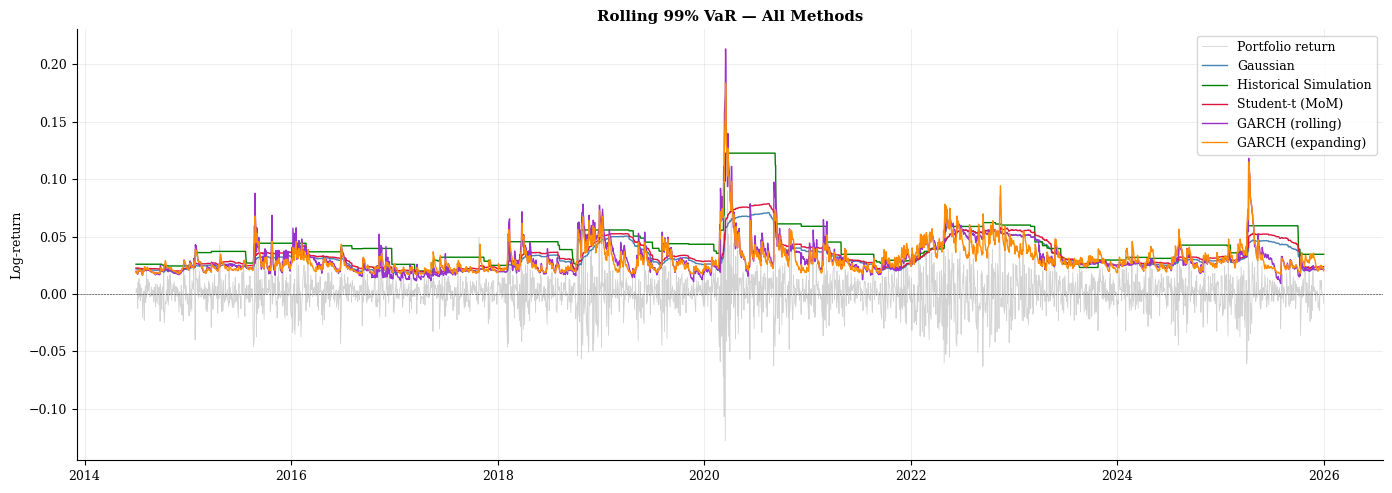

Saved: fig10_var_all_methods.png


In [15]:
# ── Figure 10: Rolling 99% VaR — All Methods ─────────────────────────────
fig10, ax10 = plt.subplots(figsize=(14, 5), facecolor='white')

ax10.plot(port_in_sample.index, port_in_sample.values,
          color='lightgrey', linewidth=0.6, label='Portfolio return', zorder=1)
for col, color, label in zip(VAR_estimates.columns, COLORS, LABELS):
    ax10.plot(VAR_estimates.index, VAR_estimates[col],
              color=color, linewidth=1.0, label=label)
ax10.axhline(0, color=DARK, linewidth=0.4, linestyle='--')
ax10.set_title('Rolling 99% VaR — All Methods', fontweight='bold')
ax10.set_ylabel('Log-return')
ax10.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig10_var_all_methods.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: fig10_var_all_methods.png')

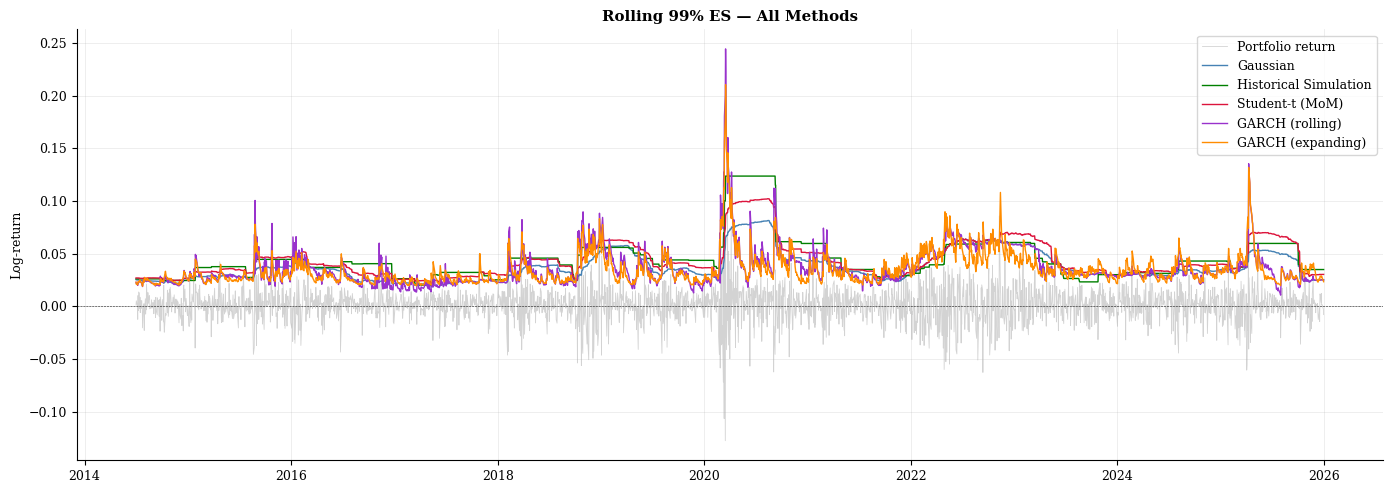

Saved: fig11_es_all_methods.png


In [16]:
# ── Figure 11: Rolling 99% ES — All Methods ──────────────────────────────
fig11, ax11 = plt.subplots(figsize=(14, 5), facecolor='white')

ax11.plot(port_in_sample.index, port_in_sample.values,
          color='lightgrey', linewidth=0.6, label='Portfolio return', zorder=1)
for col, color, label in zip(ES_estimates.columns, COLORS, LABELS):
    ax11.plot(ES_estimates.index, ES_estimates[col],
              color=color, linewidth=1.0, label=label)
ax11.axhline(0, color=DARK, linewidth=0.4, linestyle='--')
ax11.set_title('Rolling 99% ES — All Methods', fontweight='bold')
ax11.set_ylabel('Log-return')
ax11.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig11_es_all_methods.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: fig11_es_all_methods.png')

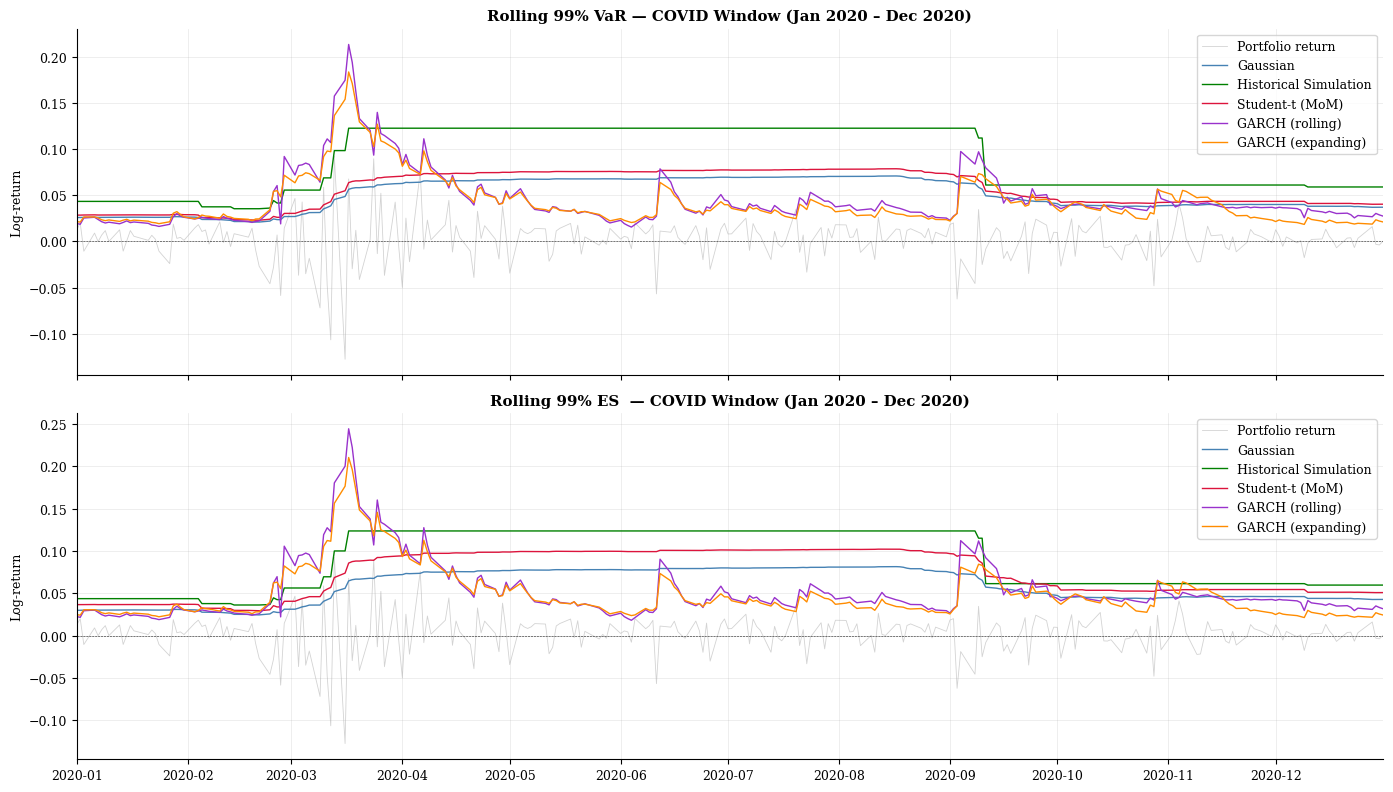

Saved: fig12_var_es_covid.png


In [17]:
# ── Figure 12: Rolling 99% VaR and ES — COVID Window (Jan–Dec 2020) ──────
fig12, axes12 = plt.subplots(2, 1, figsize=(14, 8), sharex=True, facecolor='white')

for ax, estimates, title in zip(
        axes12,
        [VAR_estimates, ES_estimates],
        ['Rolling 99% VaR — COVID Window (Jan 2020 – Dec 2020)',
         'Rolling 99% ES  — COVID Window (Jan 2020 – Dec 2020)']):

    ax.plot(port_in_sample.index, port_in_sample.values,
            color='lightgrey', linewidth=0.6, label='Portfolio return', zorder=1)
    for col, color, label in zip(estimates.columns, COLORS, LABELS):
        ax.plot(estimates.index, estimates[col],
                color=color, linewidth=1.0, label=label)
    ax.axhline(0, color=DARK, linewidth=0.4, linestyle='--')
    ax.set_xlim(pd.Timestamp('2020-01-01'), pd.Timestamp('2020-12-31'))
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Log-return')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig12_var_es_covid.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: fig12_var_es_covid.png')

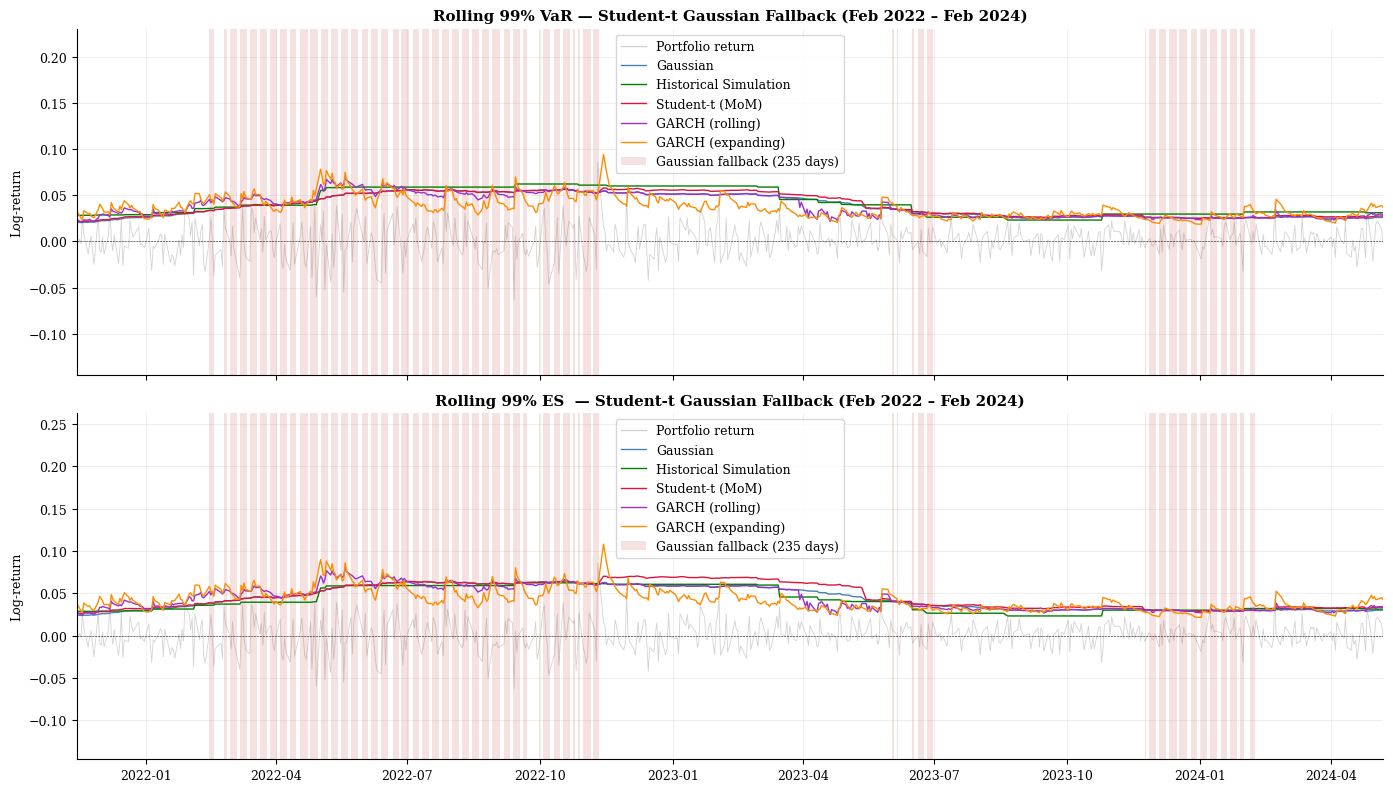

Saved: fig13_var_es_fallback.png
Fallback period: 2022-02-14 to 2024-02-07, 235 days


In [18]:
# ── Figure 13: Student-t Gaussian Fallback Period ────────────────────────
fallback_dates = results_student[results_student['fallback']].index
fb_start       = fallback_dates.min()
fb_end         = fallback_dates.max()
n_fallback     = len(fallback_dates)

plot_start = fb_start - pd.DateOffset(months=3)
plot_end   = fb_end   + pd.DateOffset(months=3)

fig13, axes13 = plt.subplots(2, 1, figsize=(14, 8), sharex=True, facecolor='white')

for ax, estimates, title in zip(
        axes13,
        [VAR_estimates, ES_estimates],
        [f'Rolling 99% VaR — Student-t Gaussian Fallback '
         f'({fb_start.strftime("%b %Y")} – {fb_end.strftime("%b %Y")})',
         f'Rolling 99% ES  — Student-t Gaussian Fallback '
         f'({fb_start.strftime("%b %Y")} – {fb_end.strftime("%b %Y")})']):

    ax.plot(port_in_sample.index, port_in_sample.values,
            color='lightgrey', linewidth=0.6, label='Portfolio return', zorder=1)
    for col, color, label in zip(estimates.columns, COLORS, LABELS):
        ax.plot(estimates.index, estimates[col],
                color=color, linewidth=1.0, label=label)
    for d in fallback_dates:
        ax.axvspan(d, d + pd.DateOffset(days=1),
                   alpha=0.15, color=RED, linewidth=0)
    ax.axhline(0, color=DARK, linewidth=0.4, linestyle='--')
    ax.set_xlim(plot_start, plot_end)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Log-return')
    ax.legend(fontsize=9, handles=[
        *[plt.Line2D([0], [0], color=c, linewidth=1.0, label=l)
          for c, l in zip(['lightgrey'] + COLORS, ['Portfolio return'] + LABELS)],
        plt.Rectangle((0, 0), 1, 1, fc=RED, alpha=0.15,
                       label=f'Gaussian fallback ({n_fallback} days)')
    ])

plt.tight_layout()
plt.savefig('fig13_var_es_fallback.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: fig13_var_es_fallback.png')
print(f'Fallback period: {fb_start.date()} to {fb_end.date()}, {n_fallback} days')

## 8 · VaR Violations

A violation on day t occurs when the realised return falls below the negative of the predicted VaR: I_t = 𝟙{r_t < −VaR_{α,t−1}}. Under a correctly specified model the expected violation rate is 1−α = 1%. Rates materially above 1% indicate that the model underestimates tail risk; rates materially below 1% indicate over-conservatism.

In [19]:
# =============================================================================
# VIOLATIONS
# =============================================================================

realised = ret_portfolio[ret_portfolio.index >= START_DATE]

methods = {
    'Gaussian'        : VAR_estimates['VaR_Gaussian'],
    'HS'              : VAR_estimates['VaR_HS'],
    'Student_t'       : VAR_estimates['VaR_Student_t'],
    'GARCH_rolling'   : VAR_estimates['VaR_GARCH'],
    'GARCH_expanding' : VAR_estimates['VaR_GARCH_exp'],
}

violations = {}

for name, var_series in methods.items():
    valid       = var_series.dropna()
    ret_aligned = realised.loc[valid.index]
    hit         = (ret_aligned < -valid).astype(int)
    violations[name] = hit

    n = hit.sum()
    T = len(hit)
    print(f"{name:20s} — T: {T:4d}, violations: {n:3d}, "
          f"rate: {n/T:.2%}, expected: {TAIL:.2%}")

Gaussian             — T: 2873, violations:  83, rate: 2.89%, expected: 1.00%
HS                   — T: 2873, violations:  32, rate: 1.11%, expected: 1.00%
Student_t            — T: 2873, violations:  68, rate: 2.37%, expected: 1.00%
GARCH_rolling        — T: 2873, violations:  76, rate: 2.65%, expected: 1.00%
GARCH_expanding      — T: 2873, violations:  68, rate: 2.37%, expected: 1.00%


## 9 · Backtesting

Four formal tests are applied. The Kupiec (1995) unconditional coverage test (UC) assesses whether the observed violation count N is consistent with the nominal tail probability under H₀: N ~ Binomial(T, 0.01). The Christoffersen (1998) independence test (IND) checks whether consecutive violations are serially uncorrelated. The conditional coverage test (CC) combines both. For parametric models, the Kolmogorov-Smirnov test on the probability integral transform and the Berkowitz (2001) likelihood ratio test assess full distributional adequacy. All tests are run at the 5% significance level.

In [20]:
# =============================================================================
# BACKTESTING — all methods
# =============================================================================
import sys
sys.path.append('.')
from backtest import backtest_all

# ── Recover sigma estimates for distributional tests ──────────────────────────
# Gaussian: VaR = -(mu + z_q * sigma)  ->  sigma ≈ -VaR / z_q  (mu ~ 0 daily)
# Student-t: sig_t stored in results_student, nu stored for time-varying PIT
# GARCH: sigma stored directly in both results DataFrames
# HS: no parametric sigma -> None, distributional tests skipped

sigma_dict = {
    'Gaussian'        : -results_gaussian['VaR_Gaussian'] / z_q,
    'HS'              : None,
    'Student_t'       : results_student['sig_t'].where(
                            ~results_student['fallback'],
                            -results_gaussian['VaR_Gaussian'] / z_q),
    'GARCH_rolling'   : results_garch['sigma_GARCH'],
    'GARCH_expanding' : results_garch_exp['sigma_GARCH_exp'],
}

nu_dict = {
    'Student_t' : results_student['nu'],  # np.inf on Gaussian fallback days
}

# ── Run all tests ─────────────────────────────────────────────────────────────
summary = backtest_all(violations,
                       alpha     = ALPHA,
                       returns   = realised,
                       sigma_dict = sigma_dict,
                       nu_dict   = nu_dict)

print(summary.to_string())

                    T   N    Rate  Expected    LR_uc    p_uc  reject_uc   LR_ind   p_ind  reject_ind    LR_cc    p_cc  reject_cc  KS_stat  KS_pval reject_ks    LR_berk  p_berk reject_berk
Model                                                                                                                                                                                      
Gaussian         2873  83  0.0289      0.01  68.6113  0.0000       True  11.7271  0.0006        True  80.3384  0.0000       True   0.0844      0.0      True  5346.1394     0.0        True
HS               2873  32  0.0111      0.01   0.3626  0.5471      False   0.8022  0.3704       False   1.1648  0.5586      False      NaN      NaN       NaN        NaN     NaN         NaN
Student_t        2873  68  0.0237      0.01  39.1777  0.0000       True   7.6070  0.0058        True  46.7847  0.0000       True   0.0779      0.0      True  5304.8594     0.0        True
GARCH_rolling    2873  76  0.0265      0.01  54.1143  0.0000